In [ ]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# with pd.option_context("display.max_rows", None, "display.max_columns", None):

REPORTS_DIR = Path("reports")
assert REPORTS_DIR.exists(), f"Path does not exist: {REPORTS_DIR.resolve()}"

METHODS = ["LIME", "MAPLE", "SHAP", "BreakDown"]

LOWER_IS_BETTER = {
    "AverageDrop", "AverageStability", "AvgSensitivity", "Complexity",
    "Deletion", "LocalLipschitzEstimate", "MaxSensitivity",
    "NonSensitivity", "RandomLogit", "RelativeInputStability",
    "RelativeOutputStability",
}

HIGHER_IS_BETTER = {
    "AverageGain", "AverageIncrease", "Consistency", "Faithfulness",
    "FaithfulnessEstimate", "Insertion", "MonotonicityCorrelation",
    "MuFidelity", "SensitivityN", "Sparseness", "Sufficiency",
}

BOOLEAN_METRICS = {
    "Completeness",
    "Monotonicity",
    "MonotonicityMetric",
}

# File load

## File discovery

In [49]:
files = sorted(REPORTS_DIR.rglob("*"))

inventory = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(REPORTS_DIR)),
            "extension": path.suffix,
            "size_kb": round(path.stat().st_size / 1024, 2),
            "modified_at": pd.to_datetime(path.stat().st_atime, unit="s")
        }
        for path in files
        if path.is_file()
    ]
)

display(inventory.sort_values(["extension", "path"]))
print(f"Files found: {len(inventory)}")

,path,extension,size_kb,modified_at
0,AverageDrop\AverageDrop_xai_metrics_report_202...,.csv,123.99,2026-09-30 12:25:55.429147720
1,AverageGain\AverageGain_xai_metrics_report_202...,.csv,117.19,2026-09-30 12:25:55.433134556
2,AverageIncrease\AverageIncrease_xai_metrics_re...,.csv,91.72,2026-09-30 12:25:55.436129808
3,AverageStability\AverageStability_xai_metrics_...,.csv,232.23,2026-09-30 12:25:55.436129808
4,AvgSensitivity\AvgSensitivity_xai_metrics_repo...,.csv,195.62,2026-09-30 12:25:55.439154863
5,Completeness\Completeness_xai_metrics_report_2...,.csv,93.85,2026-09-30 12:25:55.440152884
6,Complexity\Complexity_xai_metrics_report_20260...,.csv,131.22,2026-09-30 12:25:55.442142963
7,Consistency\Consistency_xai_metrics_report_202...,.csv,146.80,2026-09-30 12:25:55.446135521
8,Deletion\Deletion_xai_metrics_report_20260918_...,.csv,235.84,2026-09-30 12:25:55.445142508
10,FaithfulnessEstimate\FaithfulnessEstimate_xai_...,.csv,213.93,2026-09-30 12:25:55.449138403


Files found: 27


## Load the aggregated JSON report

In [50]:
json_files = list(REPORTS_DIR.glob("*.json"))
assert json_files, "No aggregated JSON file was found."

summary_json_path = json_files[0]

with open(summary_json_path, encoding="utf-8") as file:
    summary_json = json.load(file)

summary_wide = pd.json_normalize(summary_json['report'], max_level=0)

summary_long = summary_wide.melt(
    id_vars=['dataset_name', 'model_name', 'metric', 'metric_params'],
    value_vars=[method for method in METHODS if method in summary_wide.columns],
    var_name='method',
    value_name='summary_value'
)

summary_long['summary_value'] = pd.to_numeric(summary_long['summary_value'], errors='coerce')

print(f"Aggregated file: {summary_json_path.name}")
print(f"Aggregated rows: {len(summary_wide)}")
display(summary_wide.head())

Aggregated file: xai_metrics_report_20260624_071542.json
Aggregated rows: 450


,dataset_name,model_name,metric,metric_params,LIME,MAPLE,SHAP,BreakDown
0,AHU21,AutoEncoder,AverageDrop,"{'batch_size': 64, 'activation': None}",0.106299,0.143865,0.165058,0.194760
1,AHU21,AutoEncoder,AverageGain,"{'batch_size': 64, 'activation': None}",0.184601,0.096348,0.188170,0.179413
2,AHU21,AutoEncoder,AverageIncrease,"{'batch_size': 64, 'activation': None}",0.642857,0.414286,0.485714,0.485714
3,AHU21,AutoEncoder,AverageStability,"{'radius': 0.05, 'nb_samples': 100, 'distance'...",0.441245,0.567850,0.047340,0.079540
4,AHU21,AutoEncoder,AvgSensitivity,"{'nr_samples': 100, 'abs': False, 'normalise':...",1.130820,0.810518,1.631231,0.865631


## Load all detailed CSV reports

In [51]:
detailed_csv_paths = [
    path
    for path in REPORTS_DIR.rglob("*.csv")
    if path.parent != REPORTS_DIR
]

detailed_frames = []

for path in detailed_csv_paths:
    metric = path.parent.name
    frame = pd.read_csv(path)

    id_columns = ['dataset_name', 'model_name', 'observation', 'metric_params']
    available_methods = [col for col in METHODS if col in frame.columns]

    long_frame = frame.melt(
        id_vars=[col for col in id_columns if col in frame.columns],
        value_vars=available_methods,
        var_name='method',
        value_name='value'
    )

    long_frame['metric'] = metric
    long_frame['source_file'] = path.name
    long_frame['source_timestamp'] = path.stem.split("_")[-2] + "_" + path.stem.split("_")[-1]
    
    detailed_frames.append(long_frame)

detailed_long = pd.concat(detailed_frames, ignore_index=True)
detailed_long['numeric_value'] = pd.to_numeric(detailed_long['value'], errors='coerce')
detailed_long['is_boolean_value'] = detailed_long['value'].astype(str).isin(['True', 'False'])

print(f"Detailed CSV files: {len(detailed_csv_paths)}")
print(f"Rows in long format: {len(detailed_long):,}")
display(detailed_long.head())

Detailed CSV files: 25
Rows in long format: 109,200


,dataset_name,model_name,observation,metric_params,method,value,metric,source_file,source_timestamp,numeric_value,is_boolean_value
0,AHU21,AutoEncoder,10163,"{""activation"": null, ""batch_size"": 64}",LIME,0.0,AverageDrop,AverageDrop_xai_metrics_report_20260918_093304...,20260918_093304,0.0,False
1,AHU21,AutoEncoder,10164,"{""activation"": null, ""batch_size"": 64}",LIME,0.0,AverageDrop,AverageDrop_xai_metrics_report_20260918_093304...,20260918_093304,0.0,False
2,AHU21,AutoEncoder,10165,"{""activation"": null, ""batch_size"": 64}",LIME,0.0,AverageDrop,AverageDrop_xai_metrics_report_20260918_093304...,20260918_093304,0.0,False
3,AHU21,AutoEncoder,10172,"{""activation"": null, ""batch_size"": 64}",LIME,0.0,AverageDrop,AverageDrop_xai_metrics_report_20260918_093304...,20260918_093304,0.0,False
4,AHU21,AutoEncoder,10173,"{""activation"": null, ""batch_size"": 64}",LIME,0.0,AverageDrop,AverageDrop_xai_metrics_report_20260918_093304...,20260918_093304,0.0,False


# Initial result description

## Experimental coverage

,dataset_name,model_name,observations,metrics
0,AHU21,AutoEncoder,70,25
1,AHU21,ECOD,70,25
2,AHU21,HBOS,70,25
3,AHU21,IForest,70,25
4,AHU21,MCD,70,25
5,AHU21,VAE,70,25
6,ARAMIS20,AutoEncoder,70,25
7,ARAMIS20,ECOD,70,25
8,ARAMIS20,HBOS,70,25
9,ARAMIS20,IForest,70,25


,dataset_name,models,min_observations_per_model,max_observations_per_model
0,AHU21,6,70,70
1,ARAMIS20,6,70,70
2,MetroPT3,6,42,42


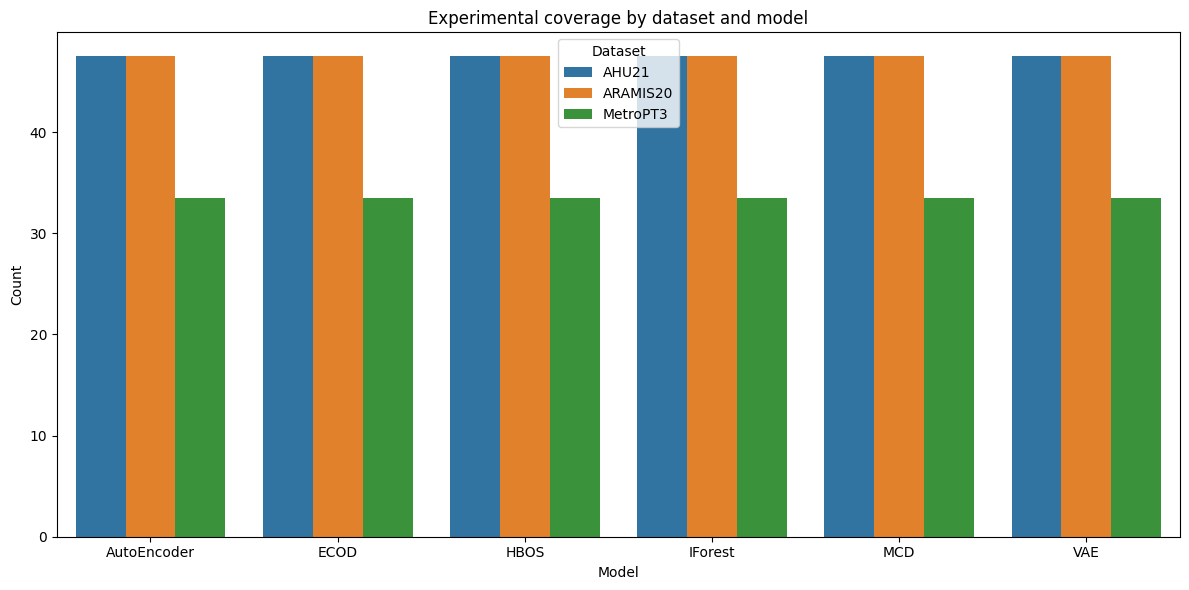

In [52]:
coverage = (
    detailed_long[['dataset_name', 'model_name', 'observation', 'metric']]
    .drop_duplicates()
    .groupby(['dataset_name', 'model_name'], as_index=False)
    .agg(observations=('observation', 'nunique'), metrics=('metric', 'nunique'))
    .sort_values(['dataset_name', 'model_name'])
)

display(coverage)

coverage_dataset = (
    coverage.groupby('dataset_name', as_index=False)
    .agg(
        models=('model_name', 'nunique'),
        min_observations_per_model=('observations', 'min'),
        max_observations_per_model=('observations', 'max')
    )
)

display(coverage_dataset)

coverage_plot = coverage.melt(
    id_vars=['dataset_name', 'model_name'],
    value_vars=['observations', 'metrics'],
    var_name='measure',
    value_name='value'
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=coverage_plot,
    x='model_name',
    y='value',
    hue='dataset_name',
    errorbar=None
)
plt.title("Experimental coverage by dataset and model")
plt.xlabel("Model")
plt.ylabel("Count")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

## Missing values and unavailable metrics

,metric,method,total,valid,missing,missing_percentage
88,SensitivityN,BreakDown,1092,0,1092,100.000000
89,SensitivityN,LIME,1092,0,1092,100.000000
90,SensitivityN,MAPLE,1092,0,1092,100.000000
91,SensitivityN,SHAP,1092,0,1092,100.000000
87,RelativeOutputStability,SHAP,1092,556,536,49.084249
80,RelativeInputStability,BreakDown,1092,577,515,47.161172
81,RelativeInputStability,LIME,1092,577,515,47.161172
83,RelativeInputStability,SHAP,1092,577,515,47.161172
85,RelativeOutputStability,LIME,1092,577,515,47.161172
86,RelativeOutputStability,MAPLE,1092,577,515,47.161172


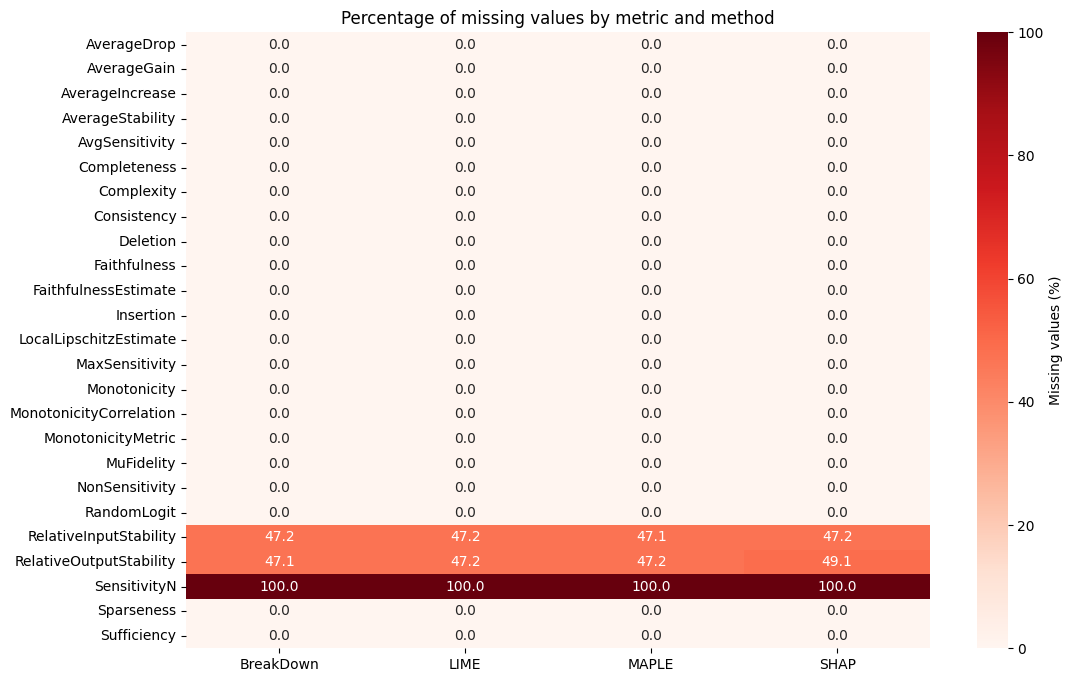

In [53]:
missingness = (
    detailed_long.groupby(['metric', 'method'], as_index=False)
    .agg(
        total=('value', 'size'),
        valid=('numeric_value', 'count'),
        missing=('numeric_value', lambda x: x.isna().sum())
    )
)

missingness['missing_percentage'] = (100 * missingness['missing'] / missingness['total'])

missingness = missingness.sort_values(['missing_percentage', 'metric', 'method'], ascending=[False, True, True])

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(missingness)

plt.figure(figsize=(12, 8))
heatmap_missing = missingness.pivot(index='metric', columns='method', values='missing_percentage')

sns.heatmap(
    heatmap_missing,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={"label": "Missing values (%)"},
)
plt.title("Percentage of missing values by metric and method")
plt.xlabel("")
plt.ylabel("")
plt.show()

## Duplicate records

In [54]:
duplicate_keys = (
    detailed_long.groupby(['metric', 'dataset_name', 'model_name', 'observation', 'method'], dropna=False)
    .size()
    .reset_index(name='count')
    .query("count > 1")
    .sort_values('count', ascending=False)
)

print(f"Duplicate keys: {len(duplicate_keys)}")
display(duplicate_keys)

if not duplicate_keys.empty:
    duplicated_rows = detailed_long.merge(
        duplicate_keys[['metric', 'dataset_name', 'model_name', 'observation', 'method']],
        on=['metric', 'dataset_name', 'model_name', 'observation', 'method'],
        how='inner'
    ).sort_values(['metric', 'dataset_name', 'model_name', 'observation', 'method'])

    display(duplicated_rows)

Duplicate keys: 0


,metric,dataset_name,model_name,observation,method,count


## Validate JSON summary values against detailed CSV mean

In [55]:
csv_means = (
    detailed_long[~detailed_long['metric'].isin(BOOLEAN_METRICS)]
    .dropna(subset=['numeric_value'])
    .groupby(['dataset_name', 'model_name', 'metric', 'method'], as_index=False)
    .agg(
        csv_mean=('numeric_value', 'mean'),
        n_valid=('numeric_value', 'size')
    )
)

summary_comparison = summary_long.merge(
    csv_means,
    on=['dataset_name', 'model_name', 'metric', 'method'],
    how='outer'
)

summary_comparison['difference'] = summary_comparison['summary_value'] - summary_comparison['csv_mean']
summary_comparison['abs_difference'] = summary_comparison['difference'].abs()
summary_comparison['matches'] = np.isclose(
    summary_comparison['summary_value'],
    summary_comparison['csv_mean'],
    atol=1e-9,
    equal_nan=True
)

comparable_rows = summary_comparison[
    summary_comparison['summary_value'].notna() & summary_comparison['csv_mean'].notna()
].copy()

comparable_rows['matches'] = np.isclose(
    comparable_rows['summary_value'],
    comparable_rows['csv_mean'],
    atol=1e-9
)

discrepancies = (comparable_rows.loc[~comparable_rows['matches']].sort_values('abs_difference', ascending=False))


print(f"Comparable rows: {len(comparable_rows)}")
print(f"Exact matches: {comparable_rows['matches'].sum()} / {len(comparable_rows)}")

display(discrepancies)

Comparable rows: 1510
Exact matches: 1510 / 1510


,dataset_name,model_name,metric,metric_params,method,summary_value,csv_mean,n_valid,difference,abs_difference,matches


# Statistics

## Global statistical summary by method and metric

In [ ]:
numeric_results = detailed_long[
    (~detailed_long['metric'].isin(BOOLEAN_METRICS)) & detailed_long['numeric_value'].notna()
].copy()

global_stats = (
    numeric_results.groupby(['metric', 'method'], as_index=False)
    .agg(
        n=('numeric_value', 'size'),
        mean=('numeric_value', 'mean'),
        median=('numeric_value', 'median'),
        std=('numeric_value', 'std'),
        p05=('numeric_value', lambda x: x.quantile(0.05)),
        p95=('numeric_value', lambda x: x.quantile(0.95)),
        min=('numeric_value', 'min'),
        max=('numeric_value', 'max')
    )
)

global_stats['direction'] = np.select(
    [global_stats['metric'].isin(LOWER_IS_BETTER), global_stats['metric'].isin(HIGHER_IS_BETTER)],
    ["lower is better", "higher is better"],
    default="unknown"
)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(global_stats.sort_values(['metric', 'method']))

## Global winner per metric

In [ ]:
def get_winners(stats, score_column):
    winner_rows = []

    for metric, group in stats.groupby('metric'):
        if metric in LOWER_IS_BETTER:
            winner = group.loc[group[score_column].idxmin()].copy()
        elif metric in HIGHER_IS_BETTER:
            winner = group.loc[group[score_column].idxmax()].copy()
        else:
            continue

        winner['metric'] = metric
        winner_rows.append(winner)

    return pd.DataFrame(winner_rows).reset_index(drop=True)

In [ ]:
mean_winners = get_winners(global_stats, "mean")
median_winners = get_winners(global_stats, "median")

winners = (
    mean_winners[['metric', 'method', 'mean', 'median', 'direction']]
    .rename(
        columns={
            "method": "winner_by_mean",
            "mean": "winner_mean",
            "median": "winner_median"
        }
    )
    .merge(
        median_winners[['metric', 'method']].rename(columns={"method": "winner_by_median"}),
        on='metric',
        how='inner'
    )
)

winners['same_winner'] = winners['winner_by_mean'] == winners['winner_by_median']

display(winners.sort_values('metric'))

plt.figure(figsize=(9, 5))
sns.countplot(
    data=winners,
    y='winner_by_mean',
    hue='winner_by_mean',
    order=winners['winner_by_mean'].value_counts().index,
    palette='viridis',
    legend=False
)
plt.title("Number of metrics won using the mean")
plt.xlabel("Number of metrics")
plt.ylabel("")
plt.show()

plt.figure(figsize=(9, 5))
sns.countplot(
    data=winners,
    y='winner_by_median',
    hue='winner_by_median',
    order=winners['winner_by_median'].value_counts().index,
    palette='viridis',
    legend=False
)
plt.title("Number of metrics won using the median")
plt.xlabel("Number of metrics")
plt.ylabel("")
plt.show()

In [ ]:
METRIC_CHARACTERISTICS = {
    # Complexity
    "Complexity": "Complexity",
    "Sparseness": "Complexity",

    # Faithfulness
    "Consistency": "Faithfulness",
    "Faithfulness": "Faithfulness",
    "FaithfulnessEstimate": "Faithfulness",
    "Monotonicity": "Faithfulness",
    "MonotonicityCorrelation": "Faithfulness",
    "MonotonicityMetric": "Faithfulness",
    "SensitivityN": "Faithfulness",
    "Sufficiency": "Faithfulness",

    # Fidelity
    "AverageDrop": "Fidelity",
    "AverageGain": "Fidelity",
    "AverageIncrease": "Fidelity",
    "Completeness": "Fidelity",
    "Deletion": "Fidelity",
    "Insertion": "Fidelity",
    "MuFidelity": "Fidelity",
    "NonSensitivity": "Fidelity",

    # Robustness
    "AverageStability": "Robustness",
    "LocalLipschitzEstimate": "Robustness",
    "MaxSensitivity": "Robustness",
    "MeGe": "Robustness",
    "RelativeInputStability": "Robustness",
    "RelativeOutputStability": "Robustness",

    # Sensitivity
    "AvgSensitivity": "Sensitivity",
    "ModelRandomization": "Sensitivity",
    "RandomLogit": "Sensitivity"
}

winner_characteristics = winners.copy()

winner_characteristics['characteristic'] = (
    winner_characteristics['metric']
    .map(METRIC_CHARACTERISTICS)
    .fillna("Other")
)

winner_counts = (
    winner_characteristics.groupby(
        ['characteristic', 'winner_by_mean'],
        as_index=False
    )
    .size()
    .rename(columns={"size": "metrics_won"})
)

characteristic_order = [
    "Complexity",
    "Faithfulness",
    "Fidelity",
    "Robustness",
    "Sensitivity"
]

plt.figure(figsize=(12, 7))
sns.barplot(
    data=winner_counts,
    y='characteristic',
    x='metrics_won',
    hue='winner_by_mean',
    order=characteristic_order,
    hue_order=METHODS,
    palette="Set2",
    errorbar=None
)
plt.title("Metric winners by XAI characteristic")
plt.xlabel("Number of metrics won")
plt.ylabel("")
plt.legend(title="Explanation method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(
    winner_counts.pivot(index='characteristic', columns='winner_by_mean', values='metrics_won')
    .fillna(0)
    .astype(int)
)

winner_characteristics = winners.copy()

winner_characteristics['characteristic'] = (
    winner_characteristics['metric']
    .map(METRIC_CHARACTERISTICS)
    .fillna("Other")
)

winner_counts = (
    winner_characteristics.groupby(
        ['characteristic', 'winner_by_median'],
        as_index=False
    )
    .size()
    .rename(columns={"size": "metrics_won"})
)

characteristic_order = [
    "Complexity",
    "Faithfulness",
    "Fidelity",
    "Robustness",
    "Sensitivity"
]

plt.figure(figsize=(12, 7))
sns.barplot(
    data=winner_counts,
    y='characteristic',
    x='metrics_won',
    hue='winner_by_median',
    order=characteristic_order,
    hue_order=METHODS,
    palette="Set2",
    errorbar=None
)
plt.title("Metric winners by XAI characteristic")
plt.xlabel("Number of metrics won")
plt.ylabel("")
plt.legend(title="Explanation method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(
    winner_counts.pivot(index='characteristic', columns='winner_by_median', values='metrics_won')
    .fillna(0)
    .astype(int)
)

## Global ranking heatmap

In [ ]:
ranking_rows = []

for metric, group in global_stats.groupby('metric'):
    if metric in LOWER_IS_BETTER:
        ranked = group.assign(rank=group['median'].rank(method='average'))
    elif metric in HIGHER_IS_BETTER:
        ranked = group.assign(rank=(-group['median']).rank(method='average'))
    else:
        continue

    ranking_rows.append(ranked)

ranking_data = pd.concat(ranking_rows, ignore_index=True)

rank_matrix = ranking_data.pivot(
    index='metric',
    columns='method',
    values='rank'
)

rank_matrix = rank_matrix.loc[rank_matrix.mean(axis=1).sort_values().index]

plt.figure(figsize=(9, 12))
sns.heatmap(
    rank_matrix,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    vmin=1,
    vmax=4,
    cbar_kws={"label": "Rank: 1 = best"},
)
plt.title("Metric ranking based on median values")
plt.xlabel("")
plt.ylabel("")
plt.show()

display(rank_matrix.mean(axis=0).sort_values().rename("average_rank").to_frame())

## Results by dataset

In [ ]:
dataset_stats = (
    numeric_results.groupby(['dataset_name', 'metric', 'method'], as_index=False)
    .agg(
        n=('numeric_value', 'size'),
        mean=('numeric_value', 'mean'),
        median=('numeric_value', 'median')
    )
)

dataset_winners = []

for dataset_name, dataset_group in dataset_stats.groupby('dataset_name'):
    for metric, metric_group in dataset_group.groupby('metric'):
        if metric in LOWER_IS_BETTER:
            winner = metric_group.loc[metric_group['mean'].idxmin()]
        else:
            winner = metric_group.loc[metric_group['mean'].idxmax()]

        dataset_winners.append(
            {
                "dataset_name": dataset_name,
                "metric": metric,
                "winner": winner['method'],
                "score": winner['mean']
            }
        )

dataset_winners = pd.DataFrame(dataset_winners)

display(dataset_winners.pivot(index="metric", columns="dataset_name", values="winner"))
display(dataset_winners.pivot(index="metric", columns="dataset_name", values="score"))

dataset_winner_matrix = dataset_winners.pivot(index='metric', columns='dataset_name', values='winner')

method_to_code = {method: index for index, method in enumerate(METHODS)}
winner_code_matrix = dataset_winner_matrix.apply(lambda column: column.map(method_to_code)).astype(float)

plt.figure(figsize=(9, 12))
sns.heatmap(
    winner_code_matrix,
    annot=dataset_winner_matrix,
    fmt="",
    cmap=sns.color_palette("Set2", len(METHODS)),
    cbar=False,
    linewidths=0.5,
)
plt.title("Best method by dataset and metric")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Outlier detection

In [ ]:
outlier_summary = (
    numeric_results.groupby(['metric', 'method'], as_index=False)
    .agg(
        n=('numeric_value', 'size'),
        mean=('numeric_value', 'mean'),
        median=('numeric_value', 'median'),
        p95=('numeric_value', lambda x: x.quantile(0.95)),
        p99=('numeric_value', lambda x: x.quantile(0.99)),
        max=('numeric_value', 'max')
    )
)

outlier_summary['mean_median_ratio'] = (
    outlier_summary['mean'].abs() / outlier_summary['median'].abs().replace(0, np.nan)
)

outlier_summary['max_median_ratio'] = (
    outlier_summary['max'].abs() / outlier_summary['median'].abs().replace(0, np.nan)
)

# with pd.option_context("display.max_rows", None, "display.max_columns", None):
display(outlier_summary.sort_values("max_median_ratio", ascending=False))

outlier_plot = outlier_summary.copy()
outlier_plot['max_median_ratio'] = outlier_plot['max_median_ratio'].replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=outlier_plot,
    x='median',
    y='mean',
    hue='method',
    style='method',
    s=100
)
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.title("Mean versus median by metric and method")
plt.xlabel("Median")
plt.ylabel("Mean")
plt.tight_layout()
plt.show()

top_extremes = (
    numeric_results.sort_values("numeric_value", key=np.abs, ascending=False)
    .groupby(['metric', 'method'], as_index=False)
    .head(5)
    .sort_values(['metric', 'method', 'numeric_value'])
)

# with pd.option_context("display.max_rows", None, "display.max_columns", None):
display(top_extremes[['metric', 'method', 'dataset_name', 'model_name', 'observation', 'numeric_value']])

top_outliers = (
    outlier_plot.dropna(subset=['max_median_ratio'])
    .sort_values('max_median_ratio', ascending=False)
    .head(20)
    .copy()
)

top_outliers['label'] = top_outliers['metric'] + "-" + top_outliers['method']

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_outliers,
    y="label",
    x="max_median_ratio",
    hue="method",
    dodge=False,
    legend=False,
)
plt.xscale("log")
plt.title("Top 20 outlier-prone metric-method combinations")
plt.xlabel("Absolute maximum / absolute median ratio (log scale)")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Boolean and degenerate metrics

In [ ]:
boolean_results = detailed_long[detailed_long['metric'].isin(BOOLEAN_METRICS)].copy()

normalised_values = boolean_results['value'].astype('string').str.strip().str.lower()

boolean_results['bool_value'] = normalised_values.map({"true": 1, "false": 0, "1": 1, "0": 0, "1.0": 1, "0.0": 0})

boolean_summary = (
    boolean_results.groupby(['metric', 'method'], as_index=False)
    .agg(
        n=("bool_value", "size"),
        positives=("bool_value", "sum"),
        positive_rate=("bool_value", "mean")
    )
)

boolean_summary['positive_rate_pct'] = 100 * boolean_summary['positive_rate']

display(boolean_summary.sort_values(['metric', 'method']))

boolean_pivot = boolean_summary.pivot(
    index='metric',
    columns='method',
    values='positive_rate_pct'
)

plt.figure(figsize=(9, 4))
sns.heatmap(
    boolean_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Positive rate (%)"}
)
plt.title("Boolean metrics")
plt.xlabel("")
plt.ylabel("")
plt.show()

## Final decision table

In [ ]:
decision_table = global_stats.pivot(index='metric', columns='method', values='median')

decision_table['criterion'] = np.select(
    [decision_table.index.isin(LOWER_IS_BETTER), decision_table.index.isin(HIGHER_IS_BETTER)],
    ["lower is better", "higher is better"],
    default="review"
)

decision_table['best_method'] = [
    row[METHODS].astype(float).idxmin()
    if metric in LOWER_IS_BETTER
    else row[METHODS].astype(float).idxmax()
    for metric, row in decision_table.iterrows()
]

display(decision_table)

# Automatic conclusions

In [ ]:
wins = winners['winner_by_median'].value_counts()

conclusion = f"""
## Automatic conclusions

- The method with the most median-based wins is **{wins.index[0]}**,
  with **{wins.iloc[0]}** winning metrics.

- The metrics with the highest risk of outlier-driven distortion are:

{outlier_summary.sort_values("max_median_ratio", ascending=False)
    .head(5)[['metric', 'method', 'mean_median_ratio', 'max_median_ratio']]
    .to_markdown(index=False)}

- The metrics with the highest percentaje of missing values are:

{missingness.head(8)[['metric', 'method', 'missing_percentage']].to_markdown(index=False)}

- A single ranking based on the sum of raw values should not be created:
  metrics have different scales, optimisation directions, and missing-value rates.
"""

display(Markdown(conclusion))

# Correlations

In [57]:
CORRELATION_METHOD = "spearman"
MIN_PAIRS = 30

correlation_input = numeric_results.copy()

# Average duplicate metric-observation-method records if any exist
metric_wide = correlation_input.pivot_table(
    index=['dataset_name', 'model_name', 'observation', 'method'],
    columns='metric',
    values='numeric_value',
    aggfunc='mean'
).reset_index()

metric_columns = sorted(
    column
    for column in metric_wide.columns
    if column not in ['dataset_name', 'model_name', 'observation', 'method']
)

print(f"Rows available for correlation analysis: {len(metric_wide):,}")
print(f"Numeric metrics available: {len(metric_columns)}")
print(metric_columns)
display(metric_wide)

Rows available for correlation analysis: 4,368
Numeric metrics available: 21
['AverageDrop', 'AverageGain', 'AverageIncrease', 'AverageStability', 'AvgSensitivity', 'Complexity', 'Consistency', 'Deletion', 'Faithfulness', 'FaithfulnessEstimate', 'Insertion', 'LocalLipschitzEstimate', 'MaxSensitivity', 'MonotonicityCorrelation', 'MuFidelity', 'NonSensitivity', 'RandomLogit', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']


metric,dataset_name,model_name,observation,method,AverageDrop,AverageGain,AverageIncrease,AverageStability,AvgSensitivity,Complexity,...,LocalLipschitzEstimate,MaxSensitivity,MonotonicityCorrelation,MuFidelity,NonSensitivity,RandomLogit,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
0,AHU21,AutoEncoder,10163,BreakDown,0.000000,0.328120,1.0,0.084563,0.772246,2.233124,...,1.861340,1.507429,0.044118,0.084955,3.0,0.970922,NaN,NaN,0.530557,0.927273
1,AHU21,AutoEncoder,10163,LIME,0.000000,0.381495,1.0,0.443617,0.996399,2.322274,...,7.056067,1.930040,0.357843,-0.194770,3.0,0.974382,NaN,NaN,0.542530,0.904762
2,AHU21,AutoEncoder,10163,MAPLE,0.000000,0.181149,1.0,0.248567,0.267372,1.740961,...,2.410579,1.361618,0.232843,0.074178,2.0,0.999923,NaN,NaN,0.720109,0.000000
3,AHU21,AutoEncoder,10163,SHAP,0.000000,0.274779,1.0,0.041415,1.599045,2.389480,...,1.851138,3.593856,-0.181373,0.137052,3.0,0.328665,NaN,NaN,0.514415,0.942308
4,AHU21,AutoEncoder,10164,BreakDown,0.000000,0.331560,1.0,0.081238,0.831297,2.228982,...,1.696405,1.549898,0.058824,0.082384,3.0,0.972407,NaN,NaN,0.533332,0.927273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4363,MetroPT3,VAE,2020-08-30 08:30:00,SHAP,0.684132,0.000000,0.0,0.009490,1.725289,1.926630,...,1.421964,3.350384,-0.218846,-0.234344,2.0,0.519601,1.396620,3.801698e+05,0.441223,0.000000
4364,MetroPT3,VAE,2020-08-30 19:00:00,BreakDown,0.594771,0.000000,0.0,0.011430,2.722145,2.084353,...,1.124850,5.553715,0.090909,-0.453701,0.0,0.186463,0.000778,1.725704e+02,0.364733,0.947368
4365,MetroPT3,VAE,2020-08-30 19:00:00,LIME,0.768124,0.000000,0.0,0.262379,1.124256,0.853243,...,12.732899,2.185274,0.493991,-0.085606,4.0,0.979703,5.740700,1.461034e+06,0.794698,0.000000
4366,MetroPT3,VAE,2020-08-30 19:00:00,MAPLE,0.556925,0.000000,0.0,0.652771,1.539318,1.719236,...,6.081320,1.898262,-0.474166,-0.067724,2.0,0.363713,22.176199,5.878716e+06,0.555662,1.000000


In [59]:
def compute_correlation_matrix(data, metric_columns, method='spearman', min_pairs=30):
    """
    Returns:
        correlation_matrix: Pairwise correlation values.
        sample_size_matrix: Number of valid paired observations.
    """
    # Gets only the metric values
    metric_data = data[metric_columns]

    # notna() -> returns True and False if it is not nan
    # astype(int) -> transform the True/False to 1/0
    # .T -> matrix traspose
    # .dot(...) -> for every metric pair, sum the products
    sample_size_matrix = metric_data.notna().astype(int).T.dot(metric_data.notna().astype(int))

    # Calculate the correlation for every column pair
    correlation_matrix = metric_data.corr(method=method, min_periods=min_pairs)

    return correlation_matrix, sample_size_matrix

In [ ]:
def correlation_pairs(correlation_matrix, sample_size_matrix, top_n=20):
    """
    Returns the strongest unique metric pairs by absolute correlation
    """
    correlation_matrix = correlation_matrix.rename_axis(
        index='metric_1',
        columns='metric_2'
    )

    sample_size_matrix = sample_size_matrix.rename_axis(
        index='metric_1',
        columns='metric_2'
    )

    # Mask of the correlation_matrix's upper triangle
    # k=1 excludes the diagonal
    upper_triangle = np.triu(np.ones(correlation_matrix.shape, dtype=bool), k=1)

    # Transform the matrix's useful part into a pairs table
    # .where(upper_triangle) -> apply the mask, the outer positions now are NaN
    # .stack() -> remove the NaN values and transform the matrix into a indexed series
    # ```
    #   metric_1     metric_2
    #   AverageDrop  Insertion    -0.72
    #                Complexity    0.15
    #   Insertion    Complexity   -0.08
    # ```
    # .rename('correlation') -> rename the series' values' column
    # .reset_index() -> transform the metric_1 and metric_2 index into normal columns
    pairs = correlation_matrix.where(upper_triangle).stack().rename('correlation').reset_index()

    # Adds a column with the number of valid observations used on every correlation
    pairs['n_pairs'] = pairs.apply(
        lambda row: sample_size_matrix.loc[row['metric_1'], row['metric_2']],
        axis=1
    )

    pairs['abs_correlation'] = pairs['correlation'].abs()

    return (
        pairs.dropna(subset=['correlation'])
        .sort_values('abs_correlation', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

In [66]:
def plot_correlation_heatmap(correlation_matrix, title, figsize=(14, 12)):
    plt.figure(figsize=figsize)

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Correlation coefficient"},
    )
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

## General correlation analysis

metric_1     metric_2               
AverageDrop  AverageDrop                     NaN
             AverageGain               -0.849320
             AverageIncrease           -0.904779
             AverageStability           0.105630
             AvgSensitivity             0.196485
                                          ...   
Sufficiency  RandomLogit                     NaN
             RelativeInputStability          NaN
             RelativeOutputStability         NaN
             Sparseness                      NaN
             Sufficiency                     NaN
Length: 441, dtype: float64


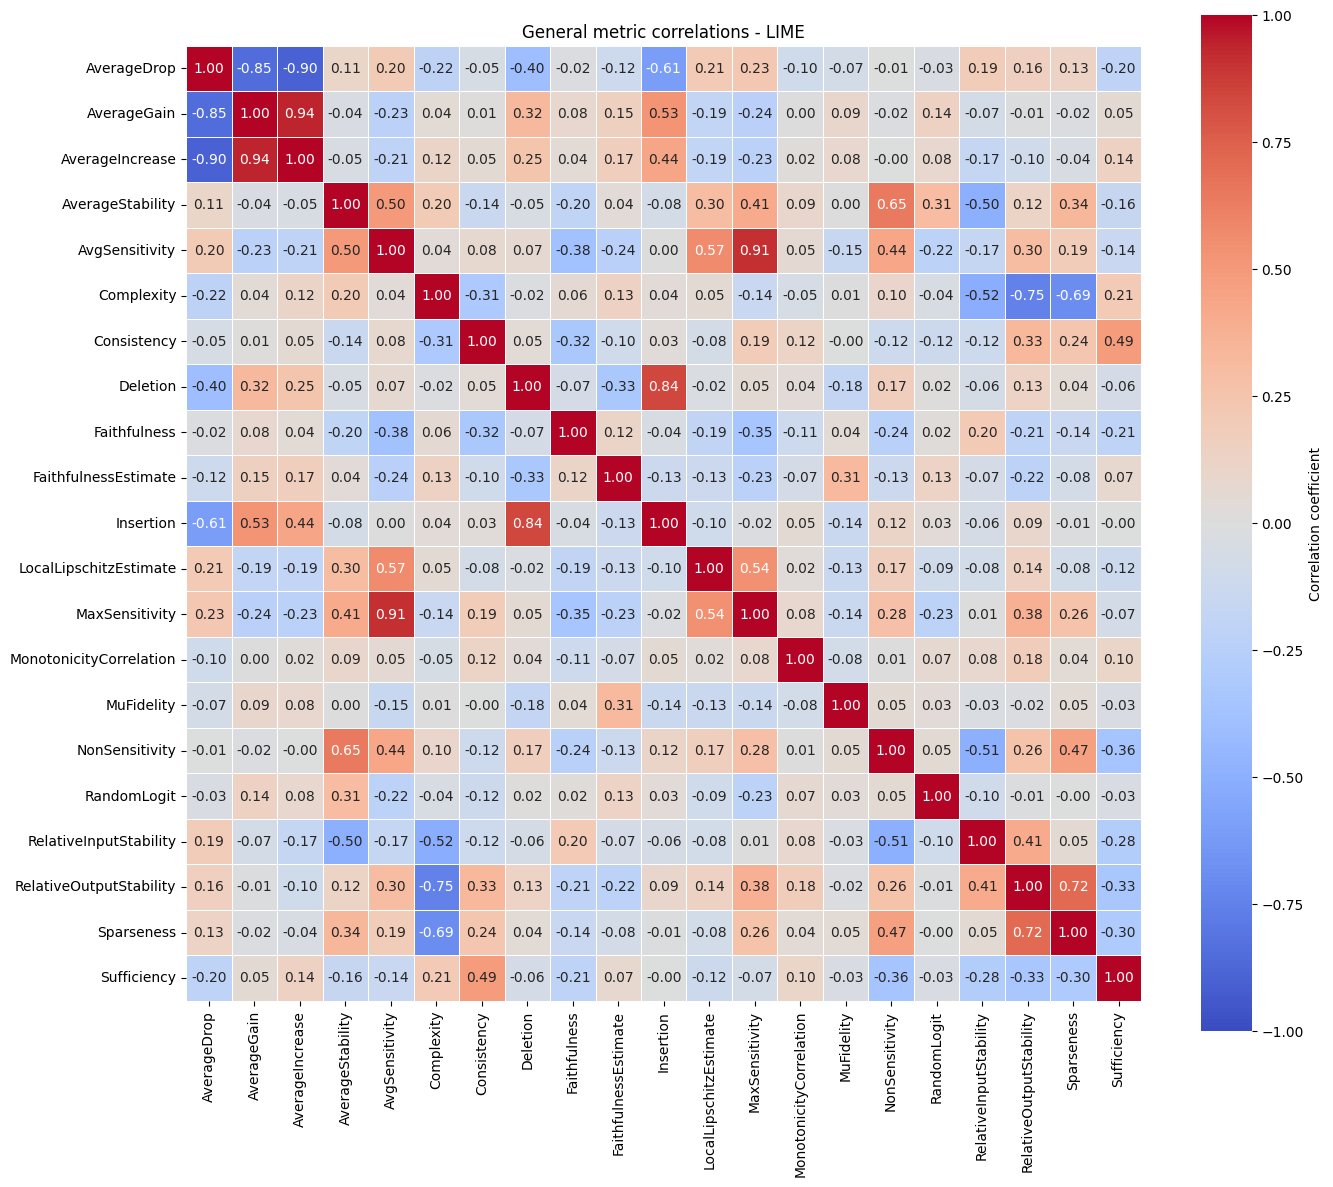

metric_1     metric_2               
AverageDrop  AverageDrop                     NaN
             AverageGain               -0.837698
             AverageIncrease           -0.874077
             AverageStability           0.285598
             AvgSensitivity             0.191973
                                          ...   
Sufficiency  RandomLogit                     NaN
             RelativeInputStability          NaN
             RelativeOutputStability         NaN
             Sparseness                      NaN
             Sufficiency                     NaN
Length: 441, dtype: float64


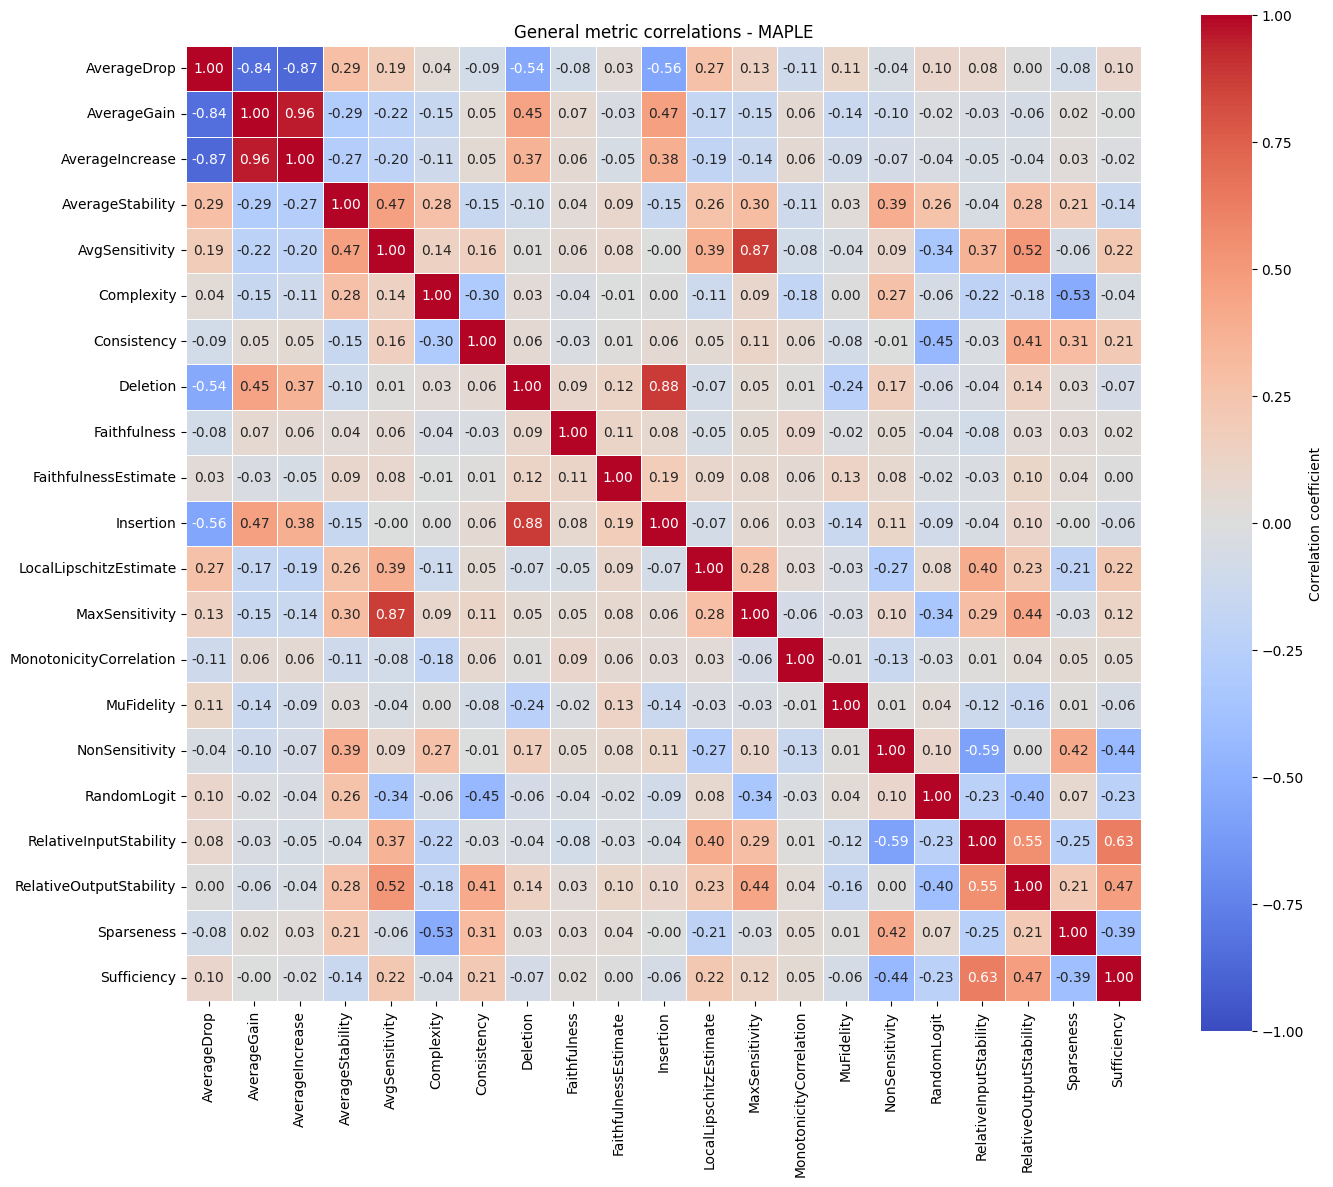

metric_1     metric_2               
AverageDrop  AverageDrop                     NaN
             AverageGain               -0.844976
             AverageIncrease           -0.892923
             AverageStability           0.181838
             AvgSensitivity             0.124559
                                          ...   
Sufficiency  RandomLogit                     NaN
             RelativeInputStability          NaN
             RelativeOutputStability         NaN
             Sparseness                      NaN
             Sufficiency                     NaN
Length: 441, dtype: float64


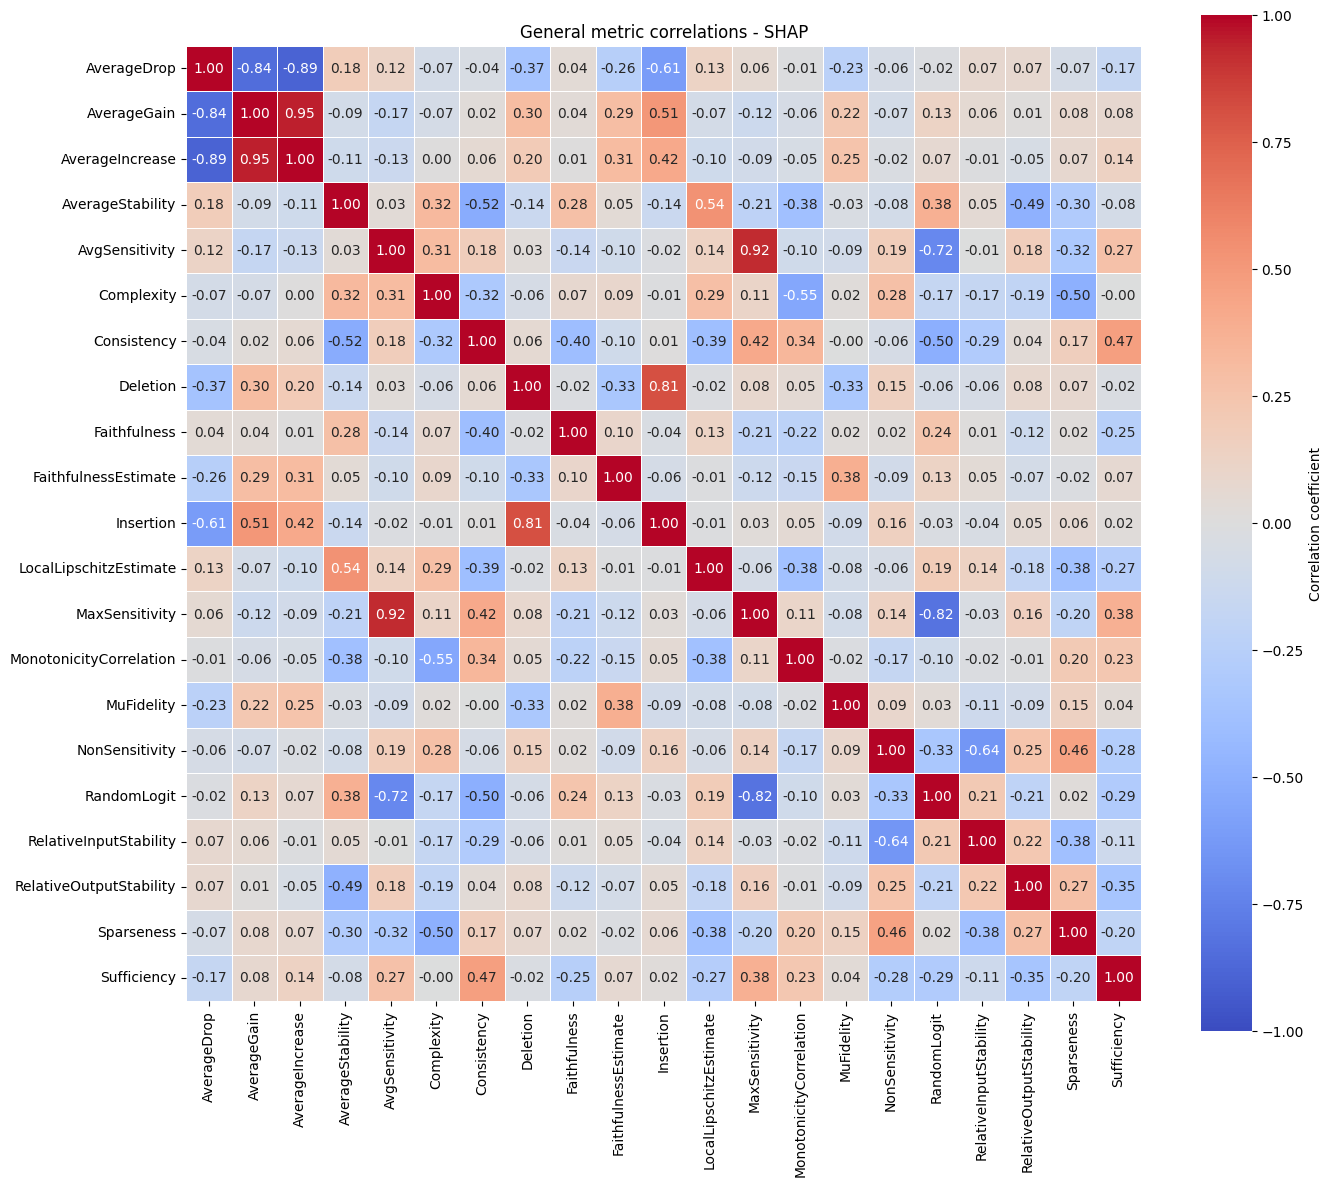

metric_1     metric_2               
AverageDrop  AverageDrop                     NaN
             AverageGain               -0.845427
             AverageIncrease           -0.894217
             AverageStability           0.190910
             AvgSensitivity             0.139053
                                          ...   
Sufficiency  RandomLogit                     NaN
             RelativeInputStability          NaN
             RelativeOutputStability         NaN
             Sparseness                      NaN
             Sufficiency                     NaN
Length: 441, dtype: float64


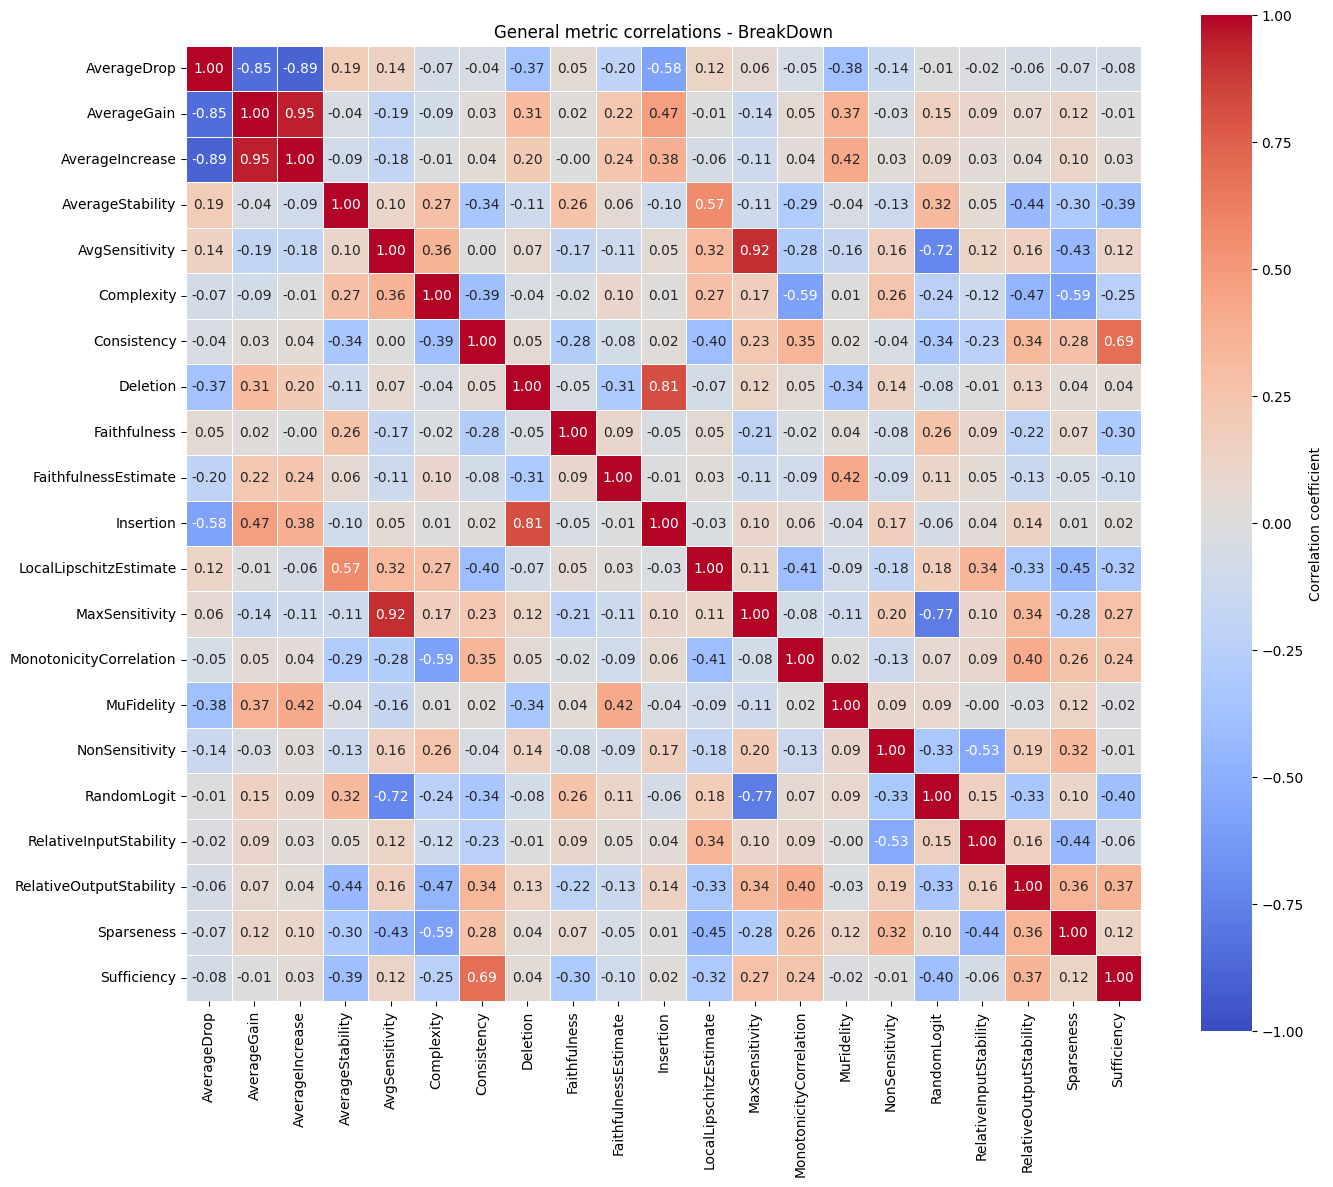

,metric_1,metric_2,correlation,n_pairs,abs_correlation,method
20,AverageGain,AverageIncrease,0.958379,1092,0.958379,MAPLE
40,AverageGain,AverageIncrease,0.946303,1092,0.946303,SHAP
60,AverageGain,AverageIncrease,0.945439,1092,0.945439,BreakDown
0,AverageGain,AverageIncrease,0.938704,1092,0.938704,LIME
41,AvgSensitivity,MaxSensitivity,0.924217,1092,0.924217,SHAP
...,...,...,...,...,...,...
78,AvgSensitivity,Sparseness,-0.434174,1092,0.434174,BreakDown
79,FaithfulnessEstimate,MuFidelity,0.421524,1092,0.421524,BreakDown
39,NonSensitivity,Sparseness,0.418522,1092,0.418522,MAPLE
58,AverageIncrease,Insertion,0.417193,1092,0.417193,SHAP


In [67]:
general_correlations = {}
general_pair_tables = []

for method in METHODS:
    method_data = metric_wide[metric_wide['method'] == method]

    correlation_matrix, sample_size_matrix = compute_correlation_matrix(
        method_data,
        metric_columns,
        method=CORRELATION_METHOD,
        min_pairs=MIN_PAIRS
    )

    general_correlations[method] = {
        "correlation": correlation_matrix,
        "n_pairs": sample_size_matrix
    }

    pairs = correlation_pairs(
        correlation_matrix,
        sample_size_matrix,
        top_n=20
    )

    pairs['method'] = method
    general_pair_tables.append(pairs)

    plot_correlation_heatmap(
        correlation_matrix,
        title=f"General metric correlations - {method}"
    )

general_top_pairs = pd.concat(
    general_pair_tables,
    ignore_index=True
).sort_values(
    ['abs_correlation', 'method'],
    ascending=[False, True]
)

display(general_top_pairs)

## General correlation comparison between methods

In [ ]:
general_summary = (
    general_top_pairs.groupby(['metric_1', 'metric_2'], as_index=False)
    .agg(
        mean_abs_correlation=('abs_correlation', 'mean'),
        min_correlation=('correlation', 'min'),
        max_correlation=('correlation', 'max'),
        methods_present=('method', 'nunique')
    )
    .sort_values(
        ['methods_present', 'mean_abs_correlation'],
        ascending=[False, False]
    )
)

display(general_summary.head(30))

## Correlations by dataset

In [ ]:
dataset_correlations = {}
dataset_top_pairs = []

for dataset_name in sorted(metric_wide['dataset_name'].unique()):
    for method in METHODS:
        subset = metric_wide[
            (metric_wide['dataset_name'] == dataset_name) & (metric_wide['method'] == method)
        ]

        correlation_matrix, sample_size_matrix = compute_correlation_matrix(
            subset,
            metric_columns,
            method=CORRELATION_METHOD,
            min_pairs=MIN_PAIRS
        )

        dataset_correlations[(dataset_name, method)] = {
            "correlation": correlation_matrix,
            "n_pairs": sample_size_matrix
        }

        pairs = correlation_pairs(
            correlation_matrix,
            sample_size_matrix,
            top_n=20
        )

        pairs['dataset_name'] = dataset_name
        pairs['method'] = method
        dataset_top_pairs.append(pairs)

dataset_top_pairs = pd.concat(
    dataset_top_pairs,
    ignore_index=True
).sort_values(
    ['dataset_name', 'method', 'abs_correlation'],
    ascending=[True, True, False]
)

display(dataset_top_pairs)

In [ ]:
for dataset_name in sorted(metric_wide['dataset_name'].unique()):
    for method in METHODS:
        result = dataset_correlations[(dataset_name, method)]

        plot_correlation_heatmap(
            result['correlation'],
            title=f"Metric correlations — Dataset: {dataset_name} | Method: {method}"
        )

## Correlations by model

In [ ]:
model_correlations = {}
model_top_pairs = []

for model_name in sorted(metric_wide['model_name'].unique()):
    for method in METHODS:
        subset = metric_wide[
            (metric_wide['model_name'] == model_name) & (metric_wide['method'] == method)
        ]

        correlation_matrix, sample_size_matrix = compute_correlation_matrix(
            subset,
            metric_columns,
            method=CORRELATION_METHOD,
            min_pairs=MIN_PAIRS
        )

        model_correlations[(model_name, method)] = {
            "correlation": correlation_matrix,
            "n_pairs": sample_size_matrix
        }

        pairs = correlation_pairs(
            correlation_matrix,
            sample_size_matrix,
            top_n=20
        )

        pairs['model_name'] = model_name
        pairs['method'] = method
        model_top_pairs.append(pairs)

model_top_pairs = pd.concat(
    model_top_pairs,
    ignore_index=True
).sort_values(
    ['model_name', 'method', 'abs_correlation'],
    ascending=[True, True, False]
)

display(model_top_pairs)

In [ ]:
for model_name in sorted(metric_wide['model_name'].unique()):
    for method in METHODS:
        result = model_correlations[(model_name, method)]

        plot_correlation_heatmap(
            result['correlation'],
            title=f"Metric correlations — Model: {model_name} | Method: {method}"
        )

## Most stable correlations across datasets

In [ ]:
dataset_stability = (
    dataset_top_pairs.groupby(['method', 'metric_1', 'metric_2'], as_index=False)
    .agg(
        datasets_present=('dataset_name', 'nunique'),
        mean_correlation=('correlation', 'mean'),
        std_correlation=('correlation', 'std'),
        min_correlation=('correlation', 'min'),
        max_correlation=('correlation', 'max'),
        mean_n_pairs=('n_pairs', 'mean')
    )
)

dataset_stability['abs_mean_correlation'] = dataset_stability['mean_correlation'].abs()

dataset_stability = dataset_stability.sort_values(
    ['datasets_present', 'abs_mean_correlation', 'std_correlation'],
    ascending=[False, False, True]
)

display(dataset_stability.head(50))